In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scenarios_and_methods import (
    generate_two_gaussian_abrupt_shift, generate_two_gaussian_slow_shift,
    generate_exchangeable_gaussian, generate_var1_dependence, generate_complex_dependence,
    risk_monitoring, plugin_martingale_test, simple_jumper_martingale_test,
    continuous_pairwise_betting_martingale_test,
    v_test, durbin_watson_test, yule_walker_test
)

# Perform tests

In [2]:
scenarios_dict = {
    "exchangeable": generate_exchangeable_gaussian,
    "two_gaussian_abrupt_shift": generate_two_gaussian_abrupt_shift,
    "generate_two_gaussian_slow_shift": generate_two_gaussian_slow_shift,
    "generate_var1_dependence": generate_var1_dependence,
    "generate_complex_dependence": generate_complex_dependence,
}

methods_dict = {
    # "plugin_martingale": plugin_martingale_test,
    # "jumper_martingale": simple_jumper_martingale_test,
    "continuous_pairwise_betting_martingale": continuous_pairwise_betting_martingale_test,
    # 'risk_monitoring': risk_monitoring,
    # 'v_test': v_test,
    # 'durbin_watson_test': durbin_watson_test,
    # 'yule_walker_test': yule_walker_test,
}

n_samples = 1000
result_list=[]
for scenario_name, generate_data in scenarios_dict.items():
    is_exchangeable_ground_truth, X_to_test, y_to_test, X_train, y_train = generate_data(n_samples=n_samples)

    for method_name, method in methods_dict.items():
        is_exchangeable, threshold, test_stat = method(
            X_to_test=X_to_test,
            y_to_test=y_to_test,
            X_train=X_train,
            y_train=y_train,
        )
        df_ = pd.DataFrame({
            "scenario": scenario_name,
            "method": method_name, 
            "is_exchangeable_ground_truth": is_exchangeable_ground_truth,
            "is_exchangeable": is_exchangeable,
            "n": np.arange(1, len(test_stat)+1),
            "test_stat": test_stat,
            "threshold":threshold,
        })
        result_list.append(df_)

df = pd.concat(result_list)

/home/alecoz/Code/MAPIE/notebooks/echangeability_test/scenarios_and_methods.py:514: RuntimeWarning: invalid value encountered in scalar divide
  return num / denum


In [3]:
{
            "scenario": scenario_name,
            "method": method_name, 
            "is_exchangeable_ground_truth": is_exchangeable_ground_truth,
            "is_exchangeable": is_exchangeable,
            "n": np.arange(1, len(test_stat)+1),
            "test_stat": test_stat,
            "threshold":threshold,
        }

{'scenario': 'generate_complex_dependence',
 'method': 'continuous_pairwise_betting_martingale',
 'is_exchangeable_ground_truth': False,
 'is_exchangeable': 1,
 'n': array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
         40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
         53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
         66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
         79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
         92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
        105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
        118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
        131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
        144, 145, 146, 147, 148,

# Show results

,ground_truth,continuous_pairwise_betting_martingale
scenario,,
exchangeable,1,1
two_gaussian_abrupt_shift,0,0
generate_two_gaussian_slow_shift,0,1
generate_var1_dependence,0,1
generate_complex_dependence,0,1


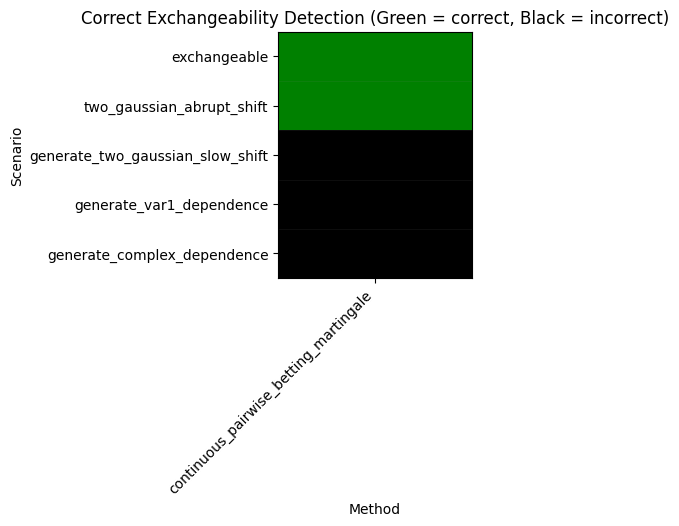

In [4]:
# Prepare pivot table for summary
summary_df = df.groupby(['scenario', 'method']).agg({
    'is_exchangeable_ground_truth': 'first',
    'is_exchangeable': 'first'
}).reset_index()

# For each scenario, collect ground truth once
gt_df = summary_df[['scenario', 'is_exchangeable_ground_truth']].drop_duplicates()
gt_df = gt_df.rename(columns={'is_exchangeable_ground_truth': 'ground_truth'})

# Pivot the methods
method_df = summary_df.pivot(index='scenario', columns='method', values='is_exchangeable')

# Join with the ground truth
final_df = method_df.join(gt_df.set_index('scenario'))

# Reorder rows to match the scenario order in scenarios_dict
final_df = final_df.loc[[s for s in scenarios_dict]]

# Reorder columns to have ground_truth first, then methods
cols = ['ground_truth'] + [col for col in final_df.columns if col != 'ground_truth']
final_df = final_df[cols]

# Convert bools to int (0: not exchangeable, 1: exchangeable)
final_df = final_df.astype(int)

display(final_df)



# Create a small grid plot summarizing correctness per scenario/method
fig, ax = plt.subplots(figsize=(2 + 0.5 * (len(cols) - 1), 0.7 + 0.5 * len(final_df)))
grid = []

# Build grid: 1 (green) if prediction matches ground_truth, 0 (black) otherwise; skip the ground_truth column itself
for i, scenario in enumerate(final_df.index):
    row = []
    for method in cols[1:]:
        correct = final_df.loc[scenario, method] == final_df.loc[scenario, 'ground_truth']
        row.append(1 if correct else 0)
    grid.append(row)
grid = np.array(grid)

# show as colored squares: green for correct, black for incorrect
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['black', 'green'])
ax.imshow(grid, cmap=cmap, aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(len(cols) - 1))
ax.set_yticks(np.arange(len(final_df.index)))
ax.set_xticklabels(cols[1:], rotation=45, ha='right')
ax.set_yticklabels(final_df.index)
ax.set_xlabel("Method")
ax.set_ylabel("Scenario")
ax.set_title("Correct Exchangeability Detection (Green = correct, Black = incorrect)")

# Minor grid for clarity
ax.set_xticks(np.arange(-.5, len(cols) - 1, 1), minor=True)
ax.set_yticks(np.arange(-.5, len(final_df.index), 1), minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.15)
ax.tick_params(which="minor", length=0)

plt.show()

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

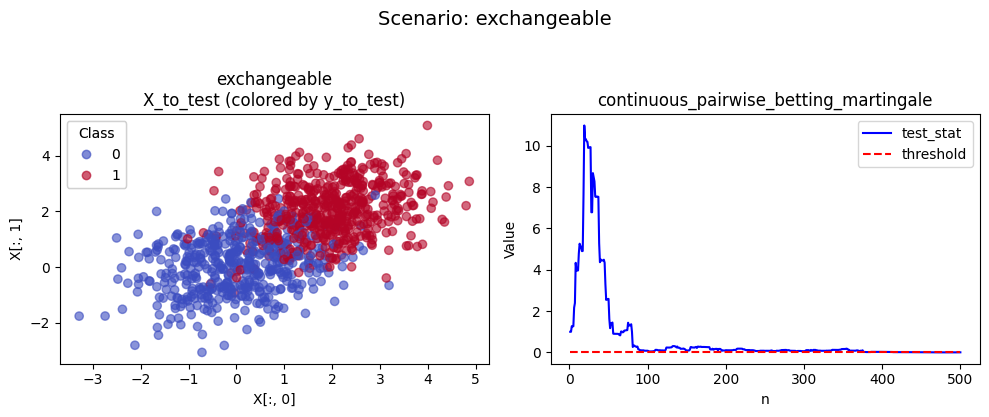

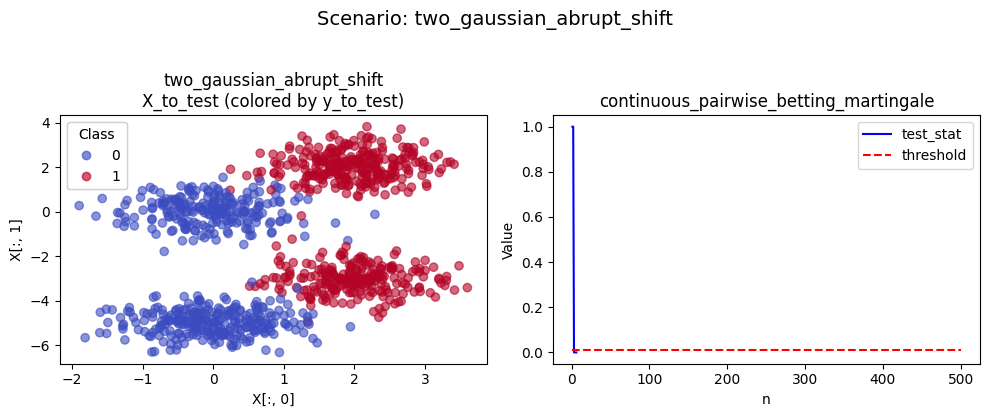

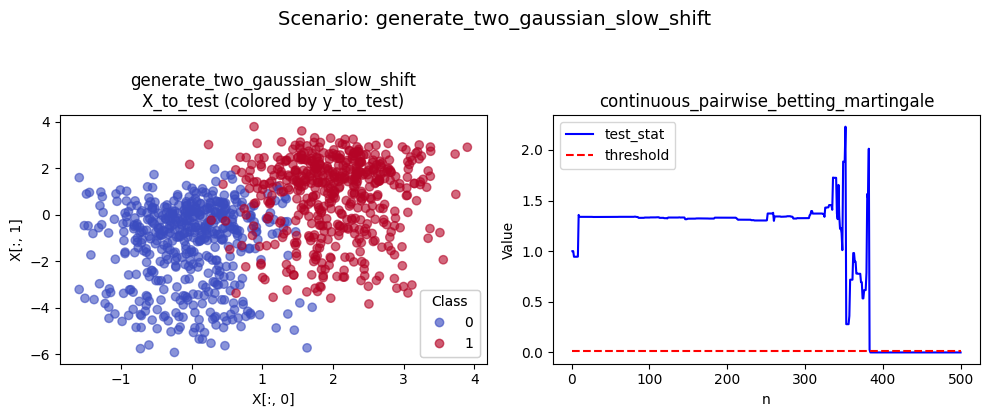

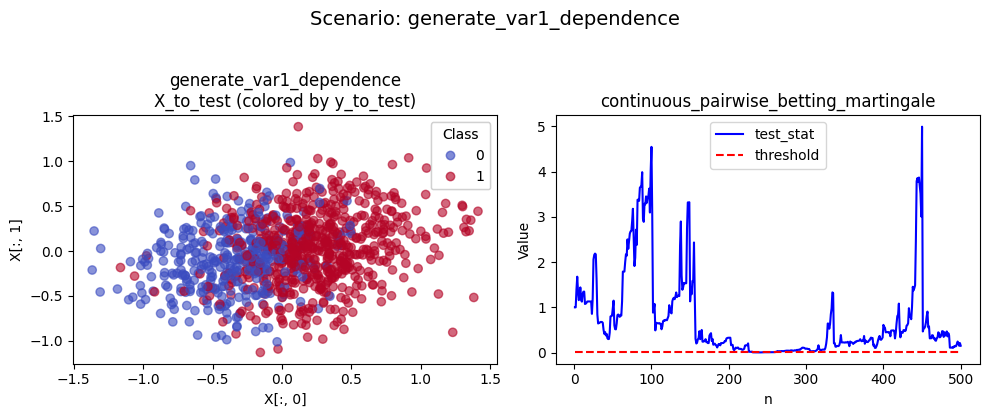

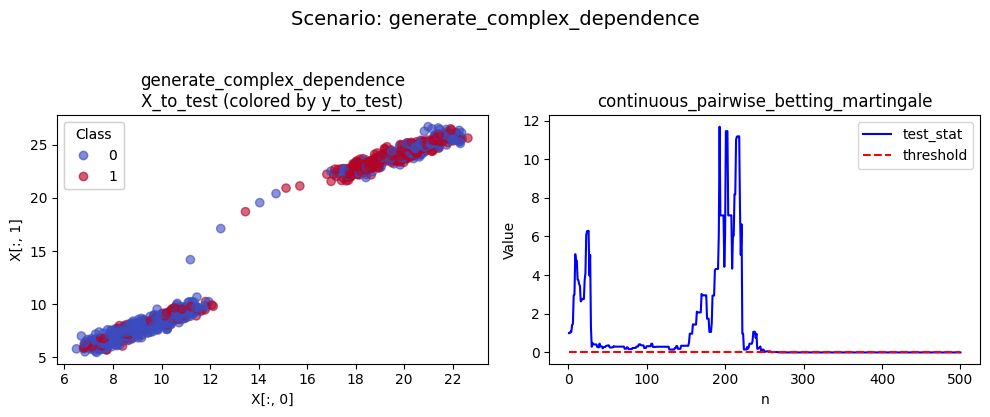

In [5]:
# For plotting, we use scenarios_dict and methods_dict below
# scenarios_dict: {scenario_name: scenario_func}
# methods_dict: {method_name: method_func}

for scenario_name, scenario_func in scenarios_dict.items():
    # Regenerate data for the scenario (with default/random_state for reproducibility)
    res = scenario_func()
    if len(res) == 5:
        is_exchangeable_ground_truth, X_to_test, y_to_test, X_train, y_train = res
    else:
        # fallback, skip plotting
        continue

    df_scenario = df[df["scenario"] == scenario_name]
    # Find method names for this scenario
    method_names = df_scenario["method"].unique()
    
    n_rows = 1
    n_cols = 1 + len(method_names)
    fig, axes = plt.subplots(
        nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4), squeeze=False
    )
    # Plot scenario data in the first column (scatter X_to_test, color by y_to_test)
    ax = axes[0, 0]
    if X_to_test.shape[1] == 2:
        scatter = ax.scatter(X_to_test[:, 0], X_to_test[:, 1], c=y_to_test, cmap='coolwarm', alpha=0.6)
        legend1 = ax.legend(*scatter.legend_elements(), title="Class")
        ax.add_artist(legend1)
    else:
        # Too many dims, just plot first two
        ax.scatter(X_to_test[:, 0], np.zeros_like(X_to_test[:, 0]), c=y_to_test, cmap='coolwarm', alpha=0.6)
    ax.set_title(f"{scenario_name}\nX_to_test (colored by y_to_test)")
    ax.set_xlabel("X[:, 0]")
    if X_to_test.shape[1] > 1:
        ax.set_ylabel("X[:, 1]")
    else:
        ax.set_ylabel("")

    # Plot test_stat vs threshold for each method
    for j, method_name in enumerate(method_names, start=1):
        ax = axes[0, j]
        df_method = df_scenario[df_scenario["method"] == method_name]
        n = df_method["n"].values
        test_stat = df_method["test_stat"].values
        threshold = df_method["threshold"].values

        # Plot test_stat and threshold as lines
        ax.plot(n, test_stat, label="test_stat", color="blue")
        ax.plot(n, threshold, label="threshold", color="red", linestyle="--")
        ax.set_title(f"{method_name}")
        ax.set_xlabel("n")
        ax.set_ylabel("Value")
        ax.legend()
    plt.suptitle(f"Scenario: {scenario_name}", fontsize=14, y=1.03)
    plt.tight_layout()
    plt.show()